In [1]:
from galpy.df import eddingtondf
from galpy.potential import NFWPotential, PlummerPotential, HernquistPotential
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
from ezfalcon.simulation import Sim

In [2]:
hostpot = NFWPotential(mvir=4, conc=10)
hostpot.turn_physical_on()

In [16]:
dmpot = PlummerPotential(amp=1e10 * u.Msun, b=10 * u.kpc)
dmpot.turn_physical_on()

In [37]:
rcutoff = 12#dmpot.rvir()#hostpot.rtide(R=20*u.kpc, z=5 * u.kpc,  M = dmpot.mass(dmpot.rvir())*u.Msun)# dmpot.rvir()#

In [38]:
ndm = 5_000

In [39]:
progpot = dmpot
dmdf = eddingtondf(pot=progpot, denspot=dmpot, rmax=rcutoff*u.kpc)

In [40]:
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import PchipInterpolator
from ezfalcon.tools import galpy_orbit_to_ezfalcon

# Evaluate vmomentdensity on a coarse grid for speed, then interpolate to a dense grid for smoothness.
r_eval = np.geomspace(1e-2, rcutoff, 34)
rho_eval = np.array([dmdf.vmomentdensity(ri * u.kpc, 0, 0) for ri in r_eval], dtype=float)

finite = np.isfinite(rho_eval)
if not np.any(finite):
    raise ValueError("vmomentdensity returned no finite values on the evaluation grid.")
if not np.all(finite):
    idx = np.flatnonzero(finite)
    rho_eval = np.interp(np.arange(len(rho_eval)), idx, rho_eval[idx])
rho_eval = np.clip(rho_eval, 1e-300, None)

rlist = np.geomspace(1e-2, rcutoff, 140) * u.kpc
rho_spline = PchipInterpolator(np.log(r_eval), np.log(rho_eval), extrapolate=False)
rho_dense = np.exp(rho_spline(np.log(rlist.to_value(u.kpc))))

finite_dense = np.isfinite(rho_dense)
if not np.any(finite_dense):
    raise ValueError("Interpolated density is non-finite on the dense grid.")
if not np.all(finite_dense):
    idx = np.flatnonzero(finite_dense)
    rho_dense = np.interp(np.arange(len(rho_dense)), idx, rho_dense[idx])

shell = 4.0 * np.pi * rho_dense * rlist.to_value(u.kpc)**2
encmass = cumulative_trapezoid(shell, rlist.to_value(u.kpc), initial=0.0)
encmass = np.maximum.accumulate(encmass)

# Build inverse CDF from vmomentdensity-derived enclosed mass.
cdf = encmass / encmass[-1]
valid = np.isfinite(cdf)
cdf = cdf[valid]
r_valid = rlist.value[valid]
mask = np.concatenate(([True], np.diff(cdf) > 1e-14))
if np.sum(mask) < 2:
    raise ValueError("CDF is not strictly increasing; adjust grid/smoothing.")
Finv = PchipInterpolator(cdf[mask], r_valid[mask], extrapolate=False)

# Sample radii and convert to galpy orbital coordinates.
u_rand = np.random.random(ndm)
rsamp = Finv(u_rand)
cos_th = 2 * np.random.random(ndm) - 1
phi = 2 * np.pi * np.random.random(ndm)
sin_th = np.sqrt(1 - cos_th**2)
x = rsamp * sin_th * np.cos(phi)
y = rsamp * sin_th * np.sin(phi)
z = rsamp * cos_th

o_samp = dmdf.sample(R=np.sqrt(x**2 + y**2)*u.kpc, phi=np.arctan2(y, x)*u.rad, z=z*u.kpc)
dm_pos, dm_vel = galpy_orbit_to_ezfalcon(o_samp)

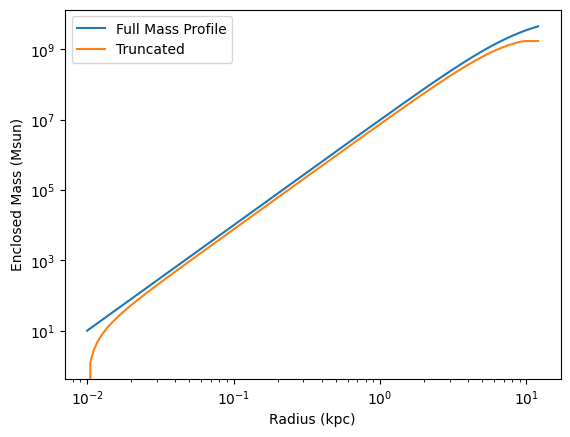

In [41]:
plt.loglog(rlist, dmpot.mass(rlist), label="Full Mass Profile")
plt.loglog(rlist, encmass, label='Truncated')
plt.xlabel("Radius (kpc)")
plt.ylabel("Enclosed Mass (Msun)")
plt.legend()

In [42]:
sim = Sim()
sim.add_particles('dm', pos=dm_pos, vel=dm_vel, mass=np.repeat(encmass[-1]/ndm, ndm))

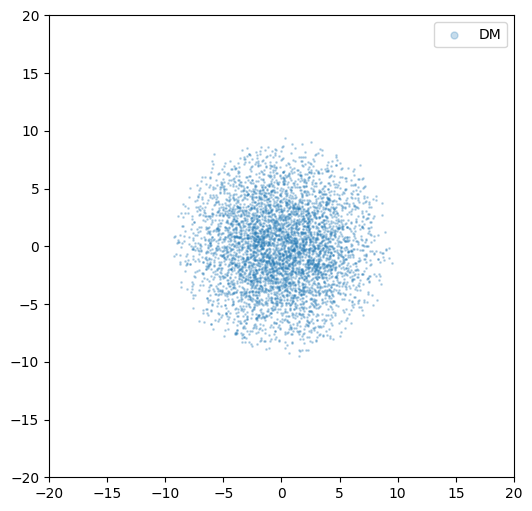

In [44]:
plt.figure(figsize=(6, 6))
plt.scatter(sim.dm.x(0), sim.dm.y(0), s=1, alpha=0.25, label='DM')

plt.xlim(-20, 20)
plt.ylim(-20, 20)
plt.legend(markerscale=5)

# Run Simulation

In [46]:
sim.run(2.0, dt=0.0005, dt_out=0.005, eps=0.1)

100%|██████████| 4000/4000 [00:36<00:00, 109.22it/s]


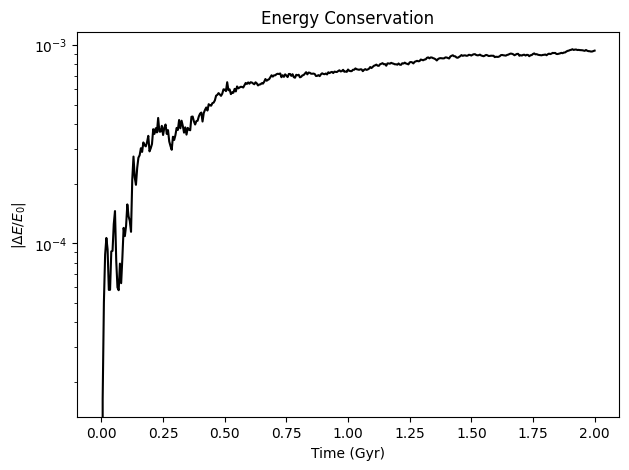

In [47]:
sim.plot_energy_diagnostic()

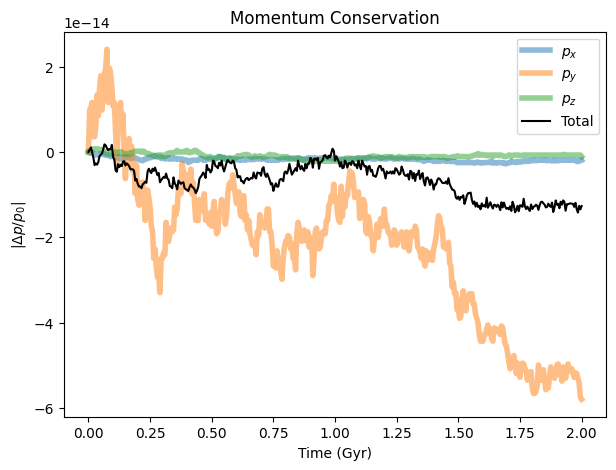

In [49]:
sim.plot_momentum_diagnostic()

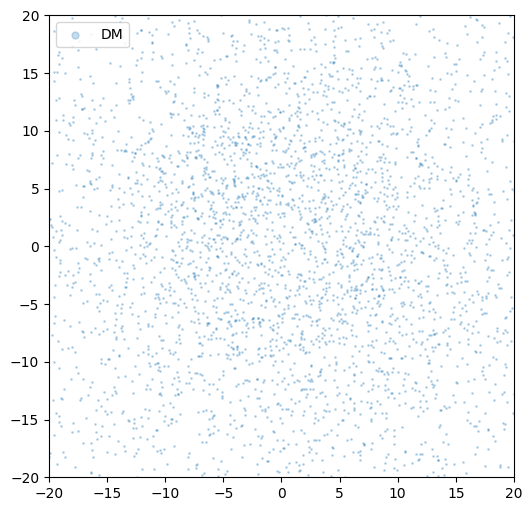

In [50]:
plt.figure(figsize=(6, 6))
plt.scatter(sim.dm.x(-1), sim.dm.y(-1), s=1, alpha=0.25, label='DM')

plt.xlim(-20, 20)
plt.ylim(-20, 20)
plt.legend(markerscale=5)

In [15]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

n_frames = len(sim.x())//2  # t_end=100, dt_out=10 -> snapshots at 0,10,...,100

fig_anim, ax_anim = plt.subplots(figsize=(6, 6))
dm_sc = ax_anim.scatter(sim.dm.x(0), sim.dm.y(0), s=1, c='k', alpha=0.25)
ax_anim.set_xlim(-25, 25)
ax_anim.set_ylim(-25, 25)
ax_anim.set_xlabel('x [kpc]', fontsize=20)
ax_anim.set_ylabel('y [kpc]', fontsize=20)
ax_anim.set_aspect('equal')
title = ax_anim.set_title('t = 0', fontsize=22)

def update(i):
    i *= 2
    dm_sc.set_offsets(list(zip(sim.dm.x(i), sim.dm.y(i))))
    title.set_text(f't = {sim.times[i]:.2f} Gyr')
    return dm_sc, title

anim = FuncAnimation(fig_anim, update, frames=n_frames, interval=100, blit=False)
plt.close(fig_anim)
fig_anim.tight_layout()
anim.save(
    'plummer_evolution_2.gif',
    writer='pillow',
    fps=15
)